In [1]:
from imports.models import *
from imports.utils import *
import adabound as Adabound

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import glob
import time
import copy
np.set_printoptions(suppress=True)

from multiprocessing import Pool
POOL_PROCESS = 23
FILE_GEN_INDEX = 2
pool = Pool(processes=POOL_PROCESS)

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
import itertools

In [2]:
X_train = np.load('../data/denoising/X_train.npy')
Y_train = np.load('../data/denoising/Y_train.npy')
X_valid = np.load('../data/denoising/X_valid.npy')
Y_valid = np.load('../data/denoising/Y_valid.npy')

In [3]:
X_train = np.expand_dims(X_train, axis=-2)
Y_train = np.expand_dims(Y_train, axis=-2)
X_valid = np.expand_dims(X_valid, axis=-2)
Y_valid = np.expand_dims(Y_valid, axis=-2)

X_train = torch.Tensor(X_train.reshape(X_train.shape[0], 2, -1)).cuda()
Y_train = torch.Tensor(Y_train.reshape(X_train.shape[0], 2, -1)).cuda()
X_valid = torch.Tensor(X_valid.reshape(X_valid.shape[0], 2, -1)).cuda()
Y_valid = torch.Tensor(Y_valid.reshape(Y_valid.shape[0], 2, -1)).cuda()

In [4]:
X_train.shape, Y_train.shape, X_valid.shape, Y_valid.shape

(torch.Size([1048576, 2, 512]),
 torch.Size([1048576, 2, 512]),
 torch.Size([8192, 2, 512]),
 torch.Size([8192, 2, 512]))

In [5]:
model = Denoise_Model().cuda()
try:
    pred = model(X_train[:128])
    print(pred.shape)
except:
    raise NameError("The input shape should be revised")
total_parameter = sum(p.numel() for p in model.parameters())
print('total_parameter: ', total_parameter / 1000000, 'M')
print(model)

torch.Size([128, 2, 512])
total_parameter:  0.03437 M
Denoise_Model(
  (conv1d_1): Conv1d(2, 64, kernel_size=(4,), stride=(1,), padding=(2,))
  (maxpooling): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1d_2): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convTrans1d_3): ConvTranspose1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convTrans1d_4): ConvTranspose1d(64, 2, kernel_size=(4,), stride=(2,), padding=(1,))
  (leakyrelu): LeakyReLU(negative_slope=0.01)
)


In [6]:
from imports.models import Denoise_Model
import torch

In [9]:
model = Denoise_Model().cuda()  # 또는 .cpu() → 추론을 CPU에서 할 경우

for name, module in model.named_modules():
    if isinstance(module, nn.Conv1d):
        print(f"{name}: Conv1d layer found!")

conv1d_1: Conv1d layer found!
conv1d_2: Conv1d layer found!


In [8]:
model.load_state_dict(torch.load('../data/models/denoise_models/denoising_model.pt'))
model.eval()  # 추론 모드로 설정 (Dropout, BatchNorm 비활성화)

Denoise_Model(
  (conv1d_1): Conv1d(2, 64, kernel_size=(4,), stride=(1,), padding=(2,))
  (maxpooling): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1d_2): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convTrans1d_3): ConvTranspose1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convTrans1d_4): ConvTranspose1d(64, 2, kernel_size=(4,), stride=(2,), padding=(1,))
  (leakyrelu): LeakyReLU(negative_slope=0.01)
)

In [23]:
import numpy as np

# 예: [128]짜리 1D noisy 데이터
exp_data = np.load('../data/exp_data_3/exp_data_32.npy')
print(exp_data.shape)

(21, 1000)


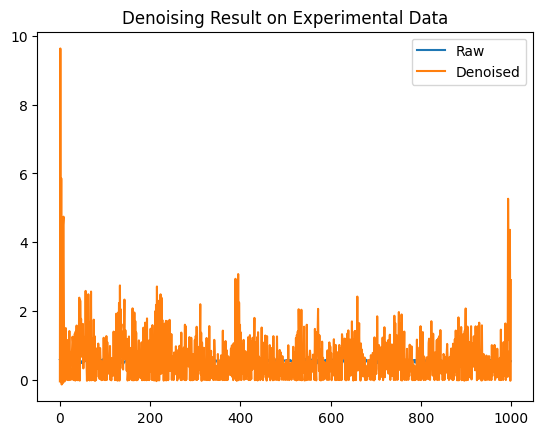

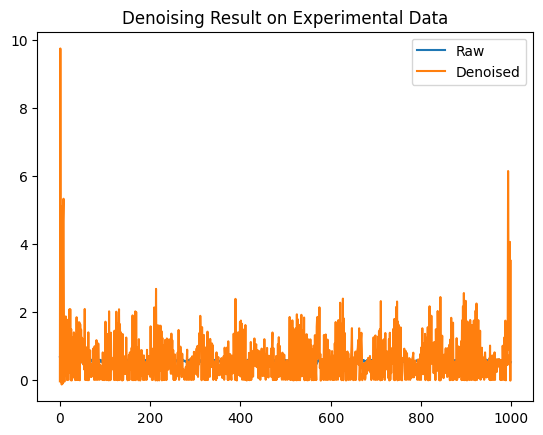

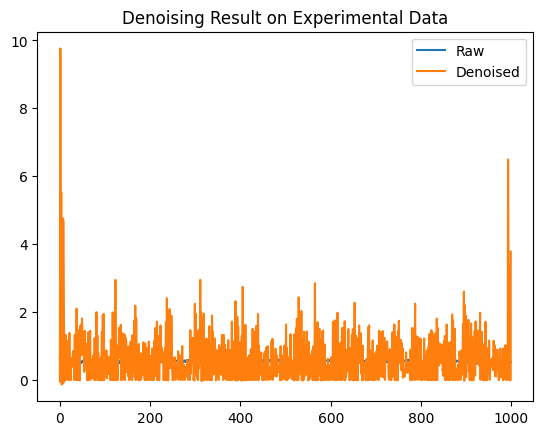

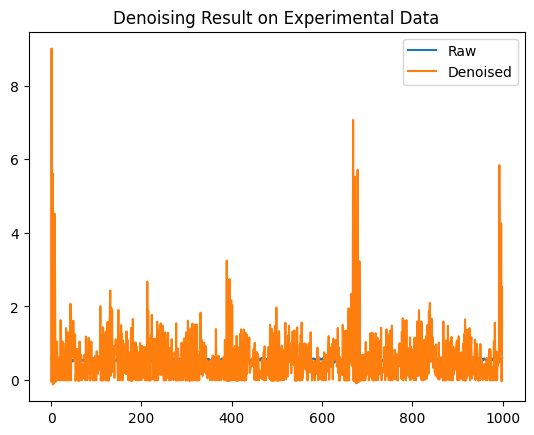

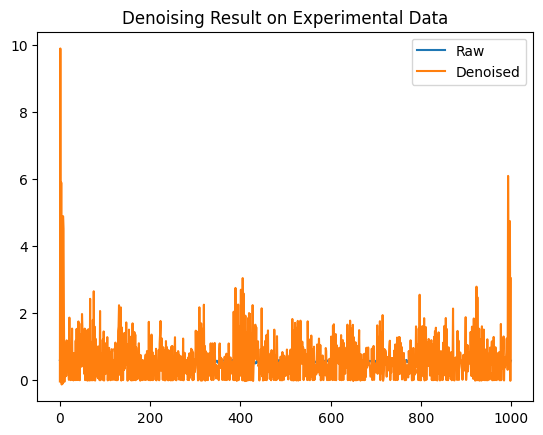

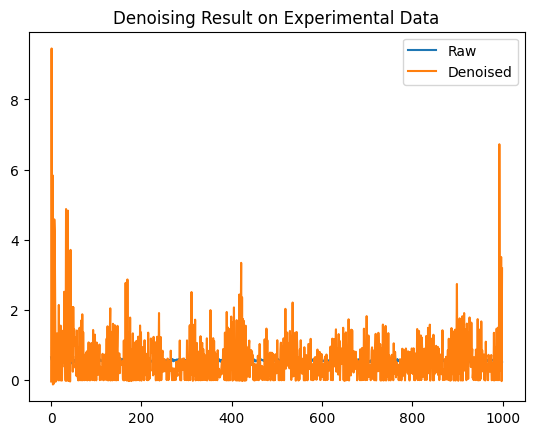

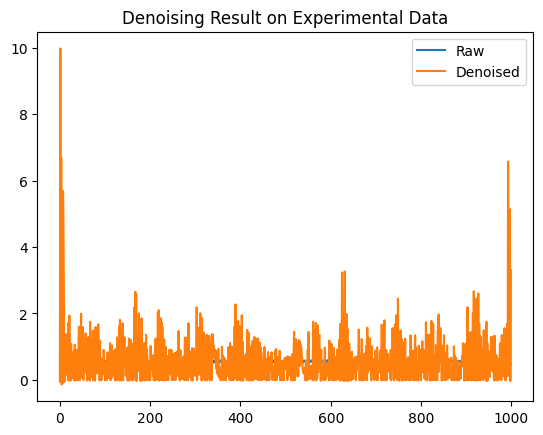

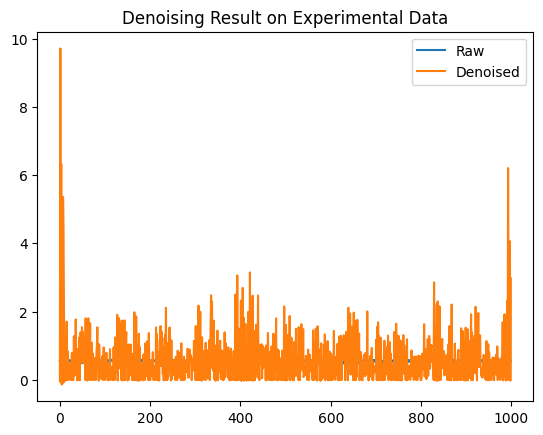

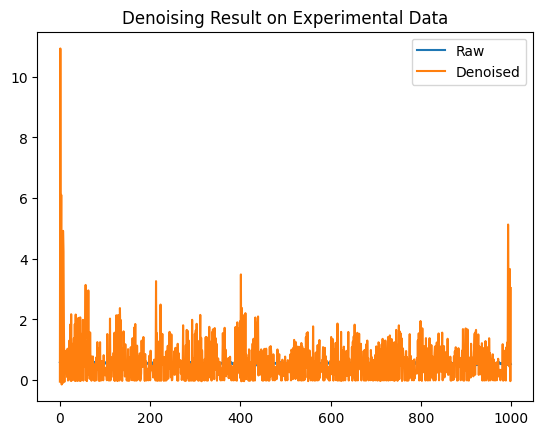

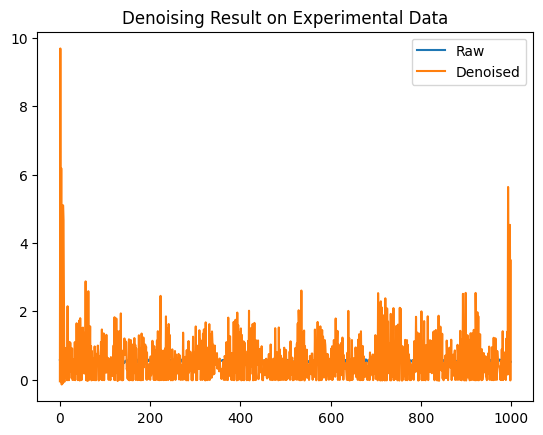

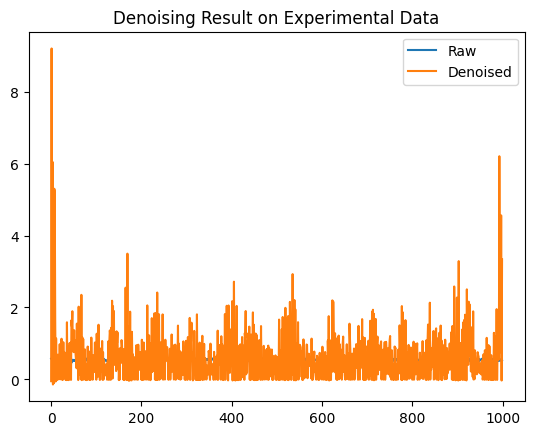

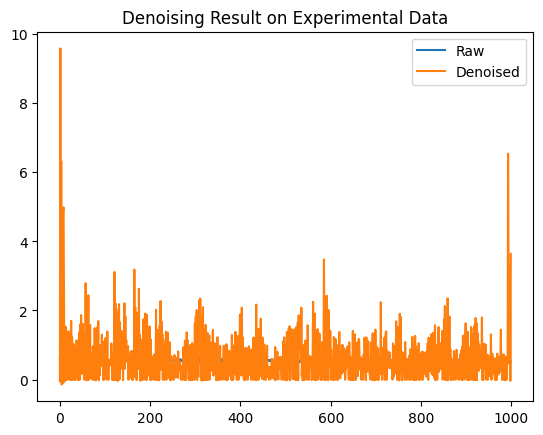

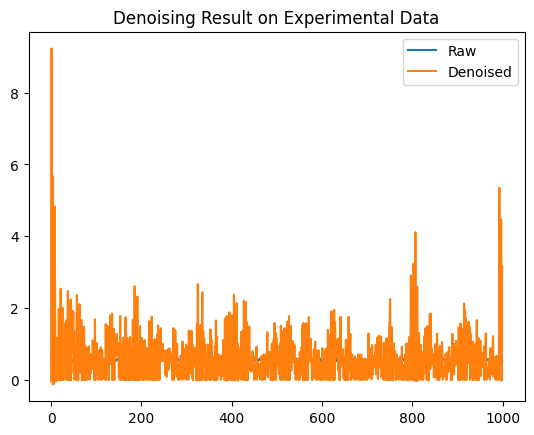

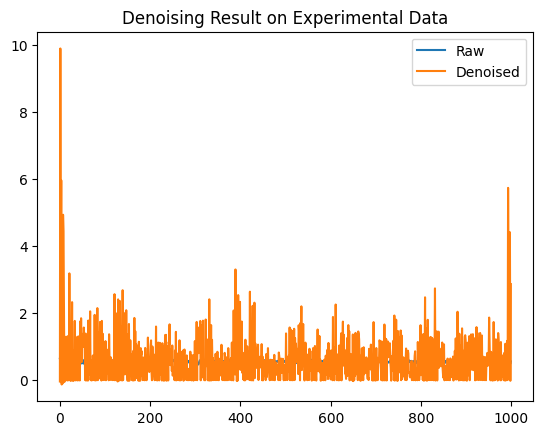

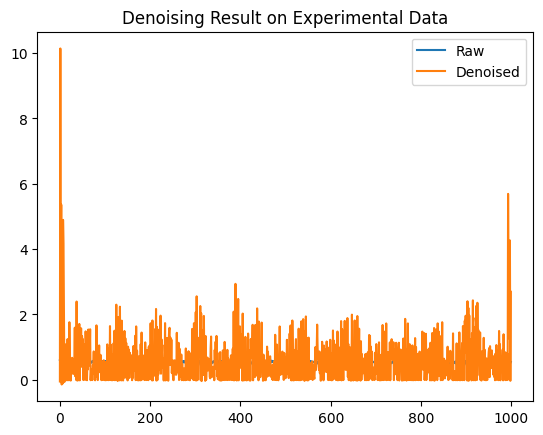

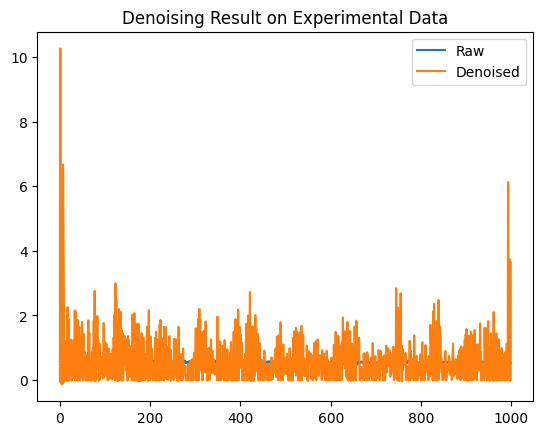

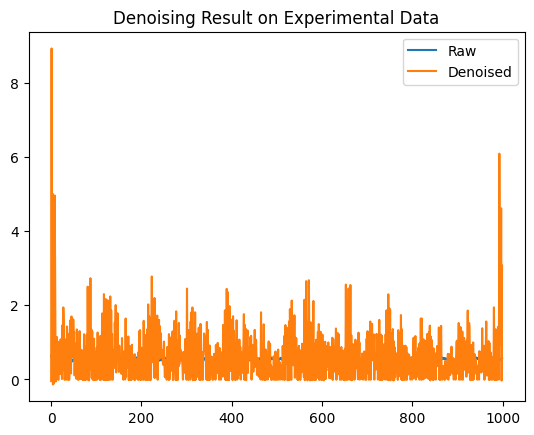

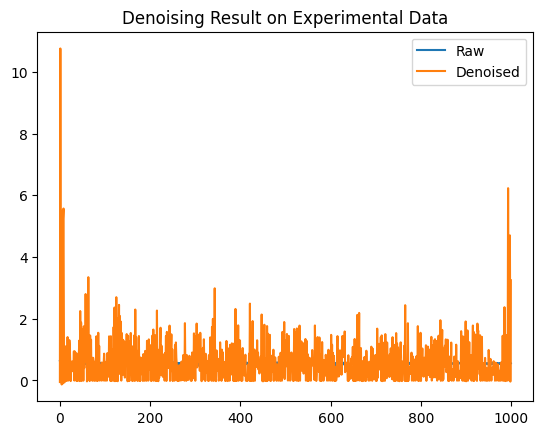

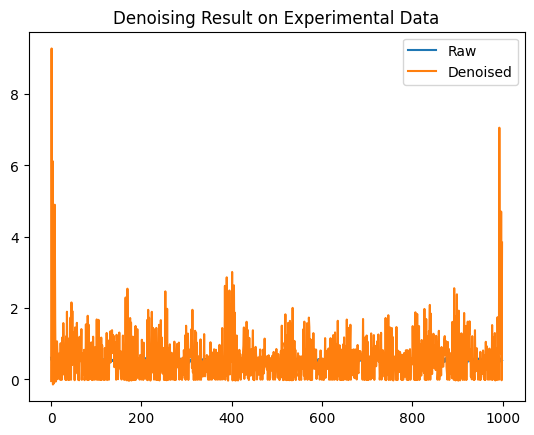

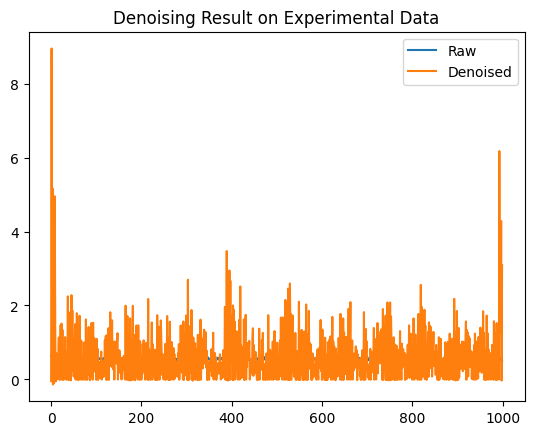

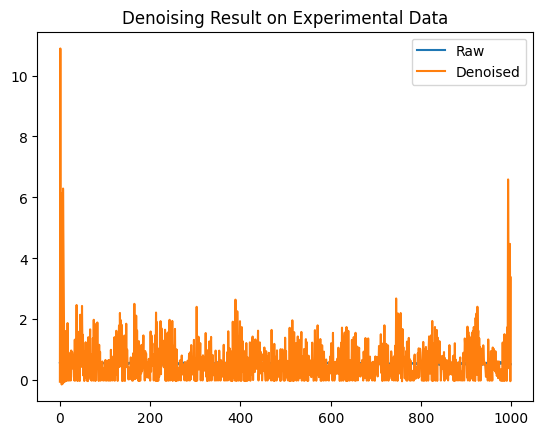

In [31]:
deno_datas = []
for i in range(len(exp_data)):
    exp_data_tensor = torch.Tensor(exp_data[i]).unsqueeze(0).repeat(2, 1).unsqueeze(0).cuda()

    with torch.no_grad():
        denoised = model(exp_data_tensor)
        denoised_np = denoised.squeeze().cpu().numpy()  # shape: (2, T)

    deno_data = denoised_np.mean(axis=0)

    plt.plot(exp_data[i], label='Raw')
    plt.plot(deno_data, label='Denoised')
    plt.legend()
    plt.title("Denoising Result on Experimental Data")
    plt.show()

    deno_datas.append(deno_data)


In [30]:
print(len(deno_datas))
print(len(deno_datas[0]))

21
2


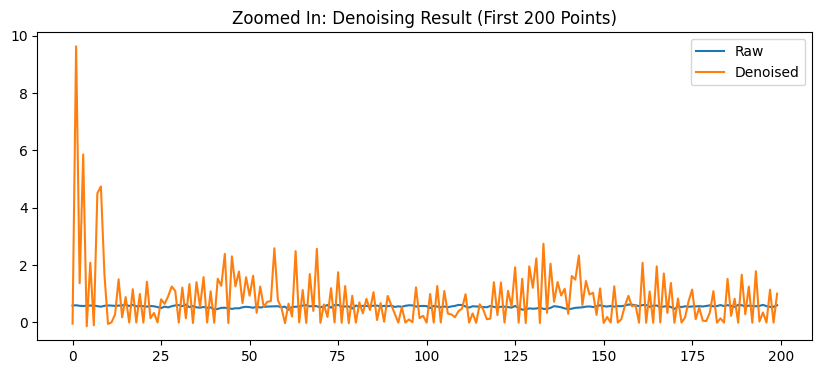

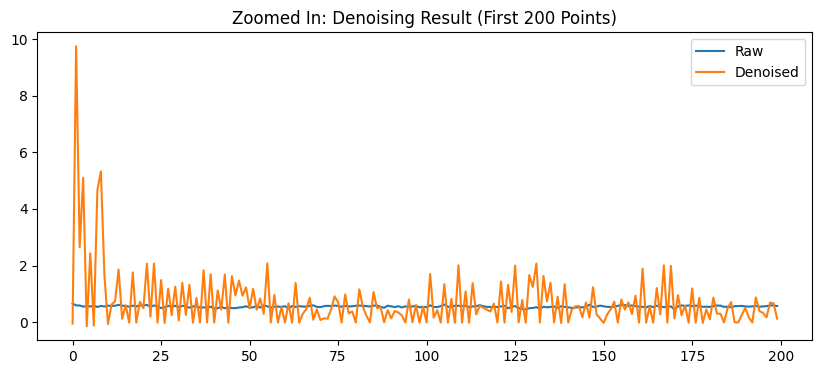

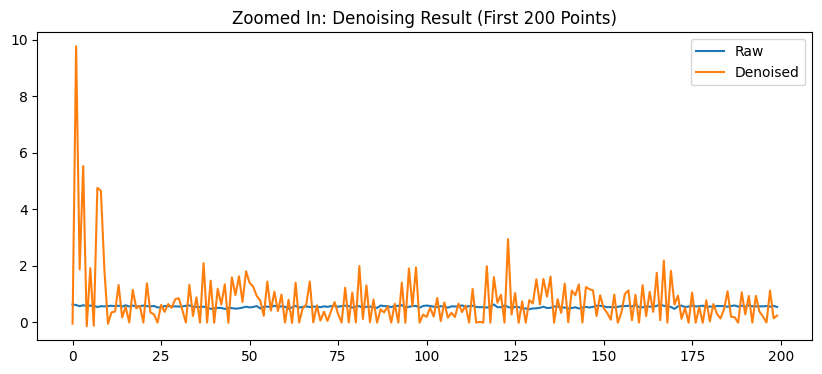

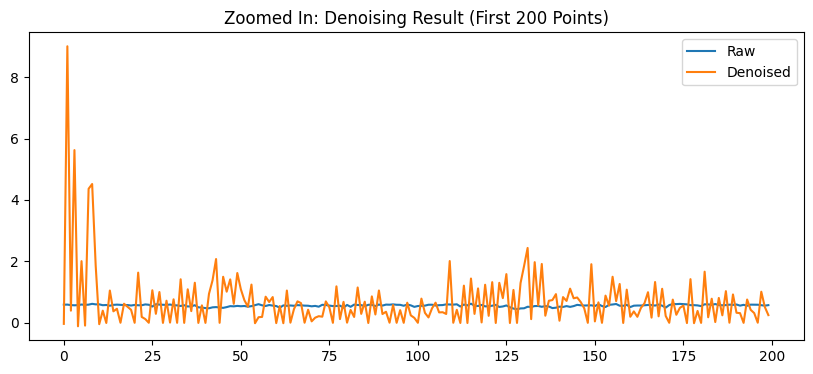

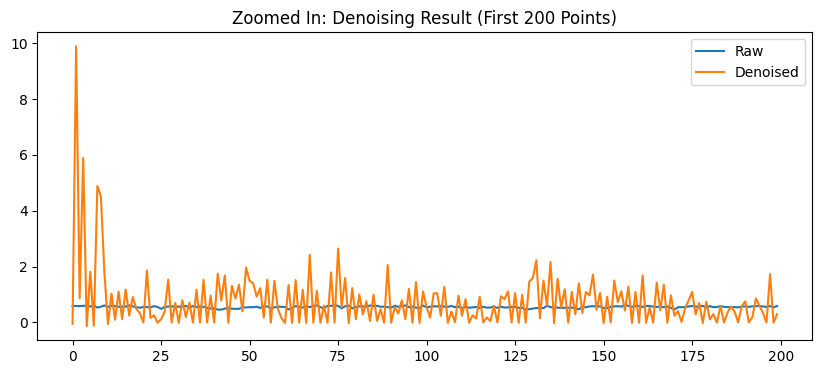

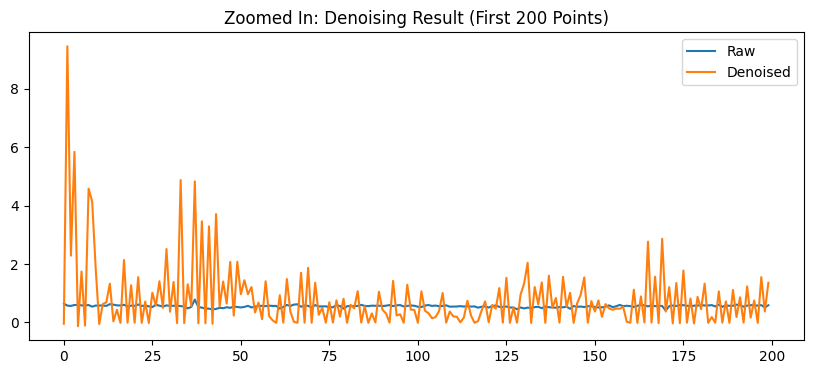

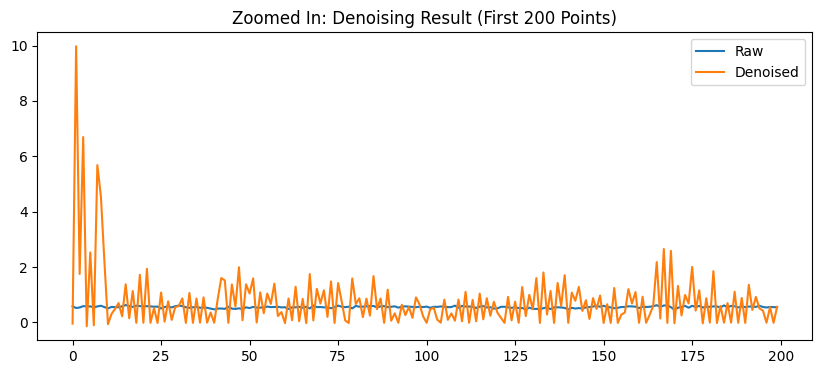

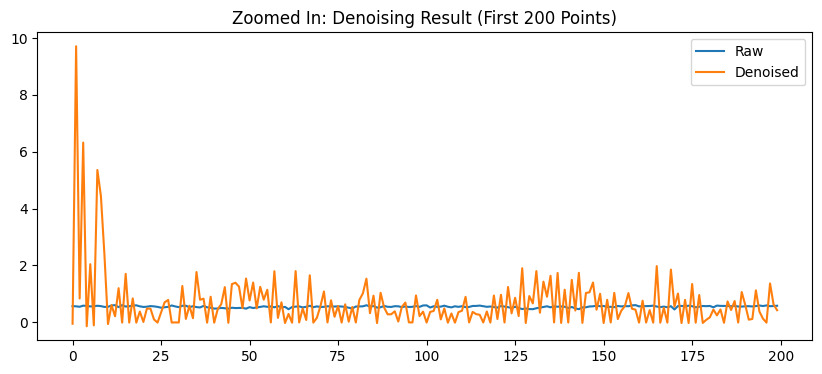

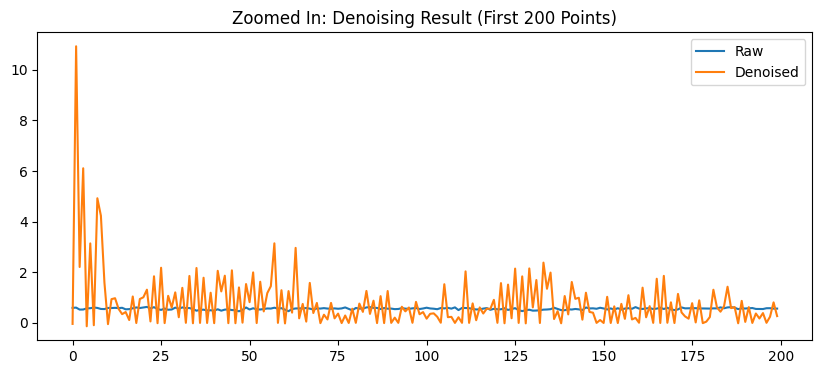

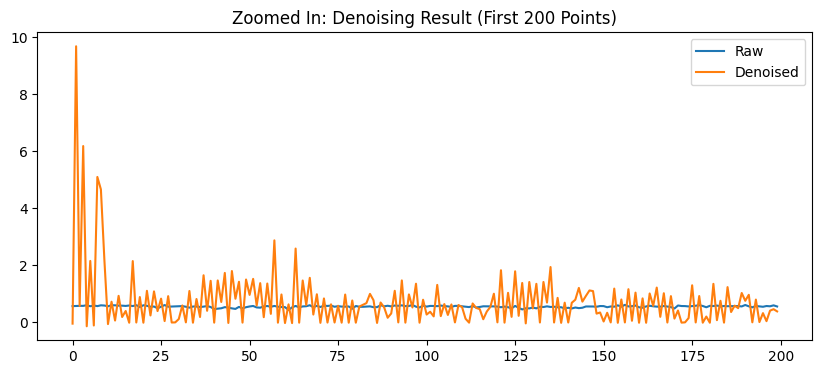

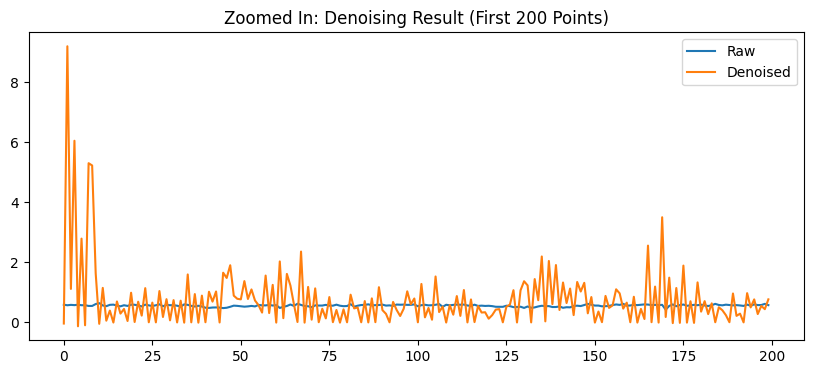

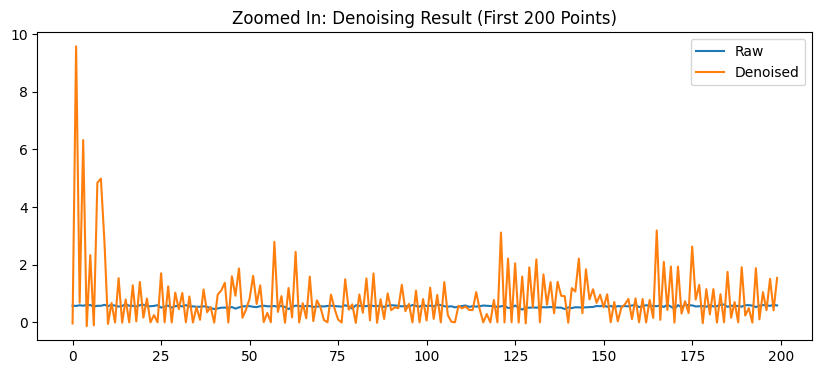

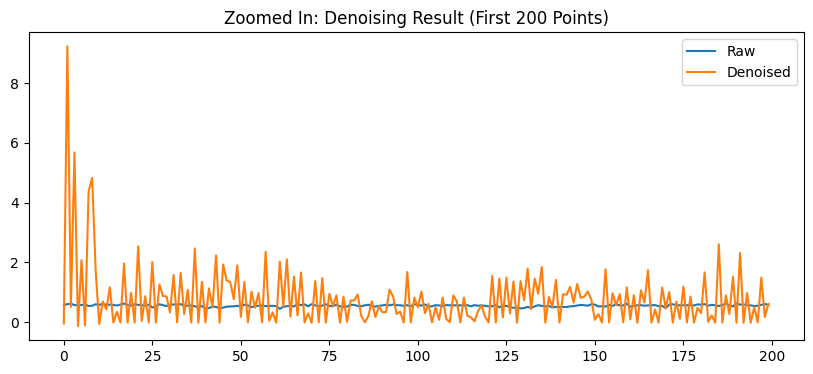

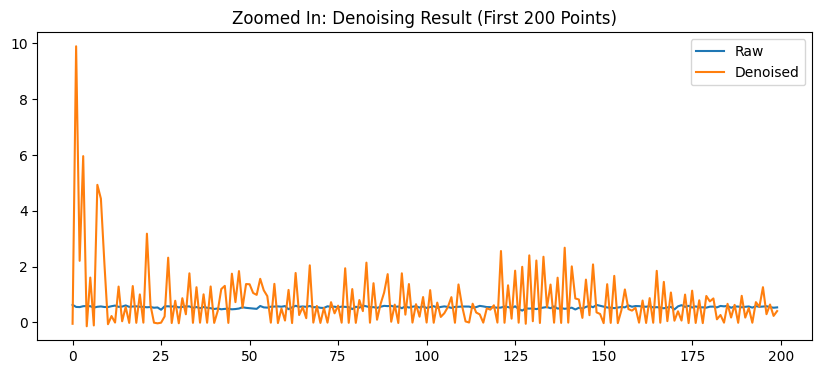

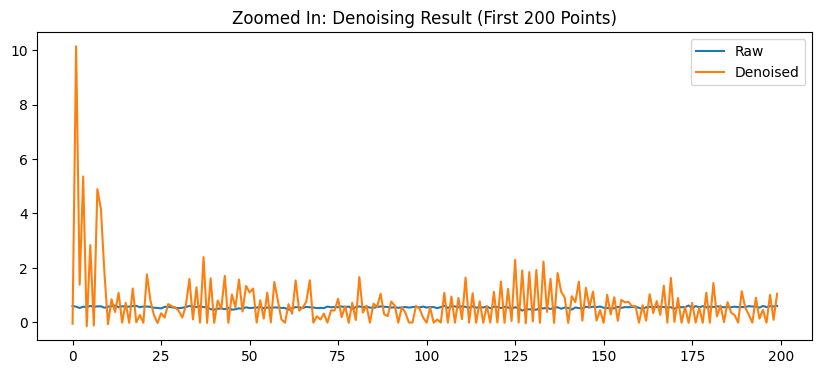

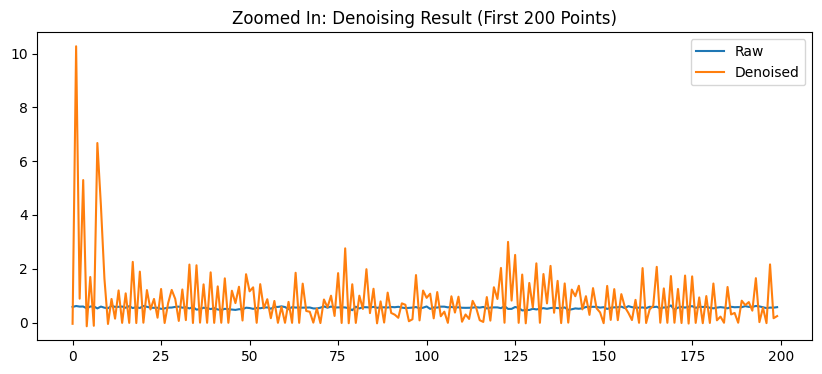

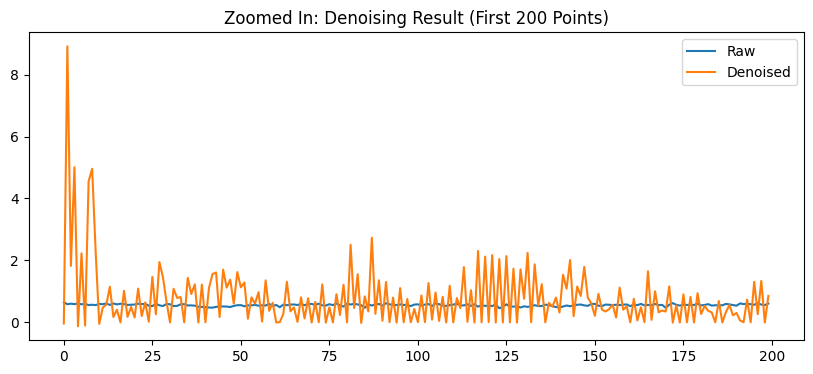

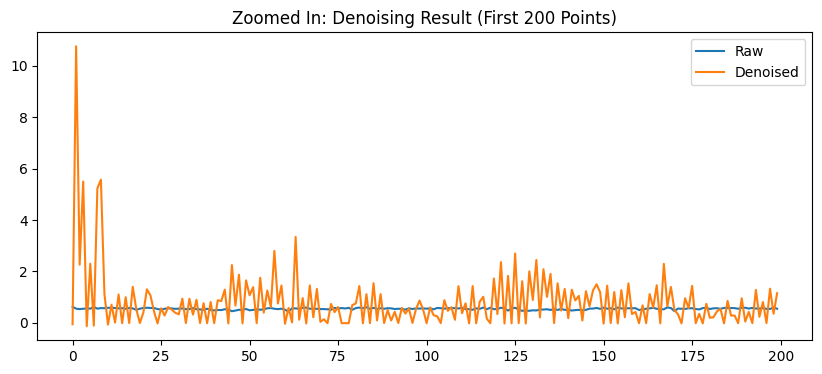

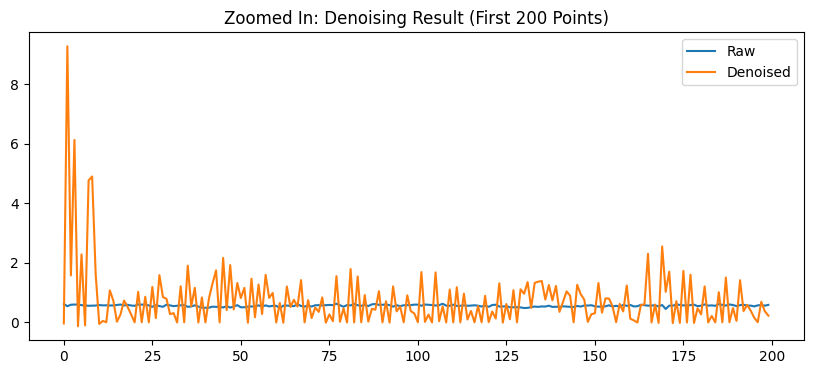

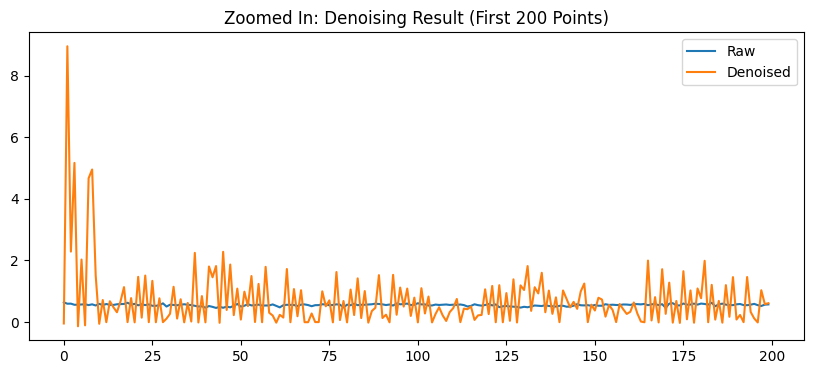

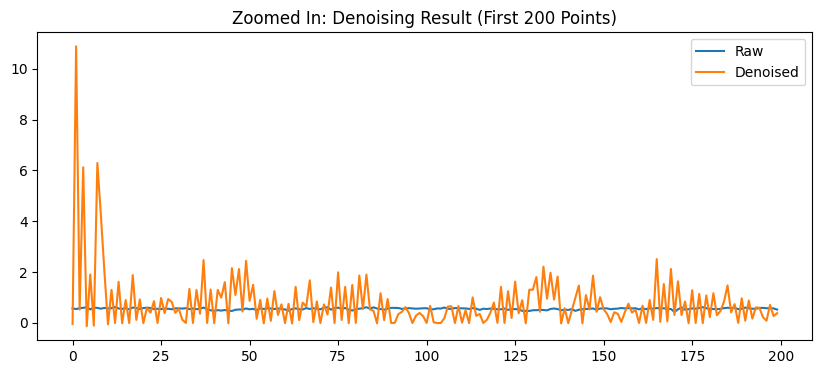

In [32]:
for i in range(len(deno_datas)):
    plt.figure(figsize=(10, 4))
    plt.plot(exp_data[i][:200], label='Raw')
    plt.plot(deno_datas[i][:200], label='Denoised')
    plt.legend()
    plt.title("Zoomed In: Denoising Result (First 200 Points)")
    plt.show()

In [33]:
print(exp_data[0])

[0.58498024 0.59543568 0.57520325 0.56957328 0.57883817 0.58490566
 0.58773784 0.56356736 0.54527163 0.57564576 0.5885947  0.58333333
 0.57254902 0.58396947 0.58627451 0.62157221 0.56767677 0.60693642
 0.5597723  0.57052632 0.56448598 0.54724409 0.56938776 0.55905512
 0.53280318 0.49818841 0.5478424  0.52112676 0.56285178 0.58823529
 0.60036496 0.5648855  0.61769912 0.5310219  0.5681382  0.52316602
 0.5093985  0.53598485 0.50630631 0.51969981 0.44363636 0.46748682
 0.50485437 0.50802139 0.49119374 0.4688057  0.49031008 0.48780488
 0.52536232 0.54110899 0.53       0.5077821  0.55069583 0.51593625
 0.53710938 0.55037313 0.55387524 0.56007394 0.56120527 0.52398524
 0.5472028  0.43942134 0.53592233 0.54216867 0.55333333 0.58364312
 0.599631   0.55577299 0.57328386 0.56007752 0.52173913 0.55809524
 0.60311284 0.51138354 0.60117878 0.60665362 0.54980843 0.55218216
 0.55477032 0.48141264 0.58490566 0.54990926 0.57471264 0.57194245
 0.55178908 0.58081705 0.5821501  0.55198488 0.57462687 0.5601

In [35]:
print(1-deno_datas[0])

[ 1.0483307  -8.635382   -0.36503923 -4.8595457   1.138576   -1.0795009
  1.105445   -3.5035777  -3.742475   -0.6709256   1.0558013   1.0023592
  0.72603804 -0.50161743  0.8275789   0.12031668  1.0089012  -0.1551007
  1.0077558   0.00957388  1.0113727  -0.41600847  0.85925406  0.67423385
  1.0065197   0.19777459  0.35548437  0.09063089 -0.25088382 -0.0971086
  1.0103811  -0.21409082  0.85886055 -0.33666646  1.0246378  -0.40060556
  0.45028943 -0.57588065  1.0101994  -0.0827781   1.0152328  -0.5215486
 -0.27416134 -1.3862355   1.0261528  -1.3030944  -0.25458813 -0.7708893
  0.32987982 -0.57323074  0.0718841  -0.623108    0.6704308  -0.24736917
  0.4641822   0.2836684   0.26058918 -1.5836644   0.23218554  0.50025153
  1.0309548   0.34802926  0.7953895  -1.4861293   1.0041552  -0.1265217
  1.020602   -0.6835278   0.60193604 -1.5642941   1.0161841   0.37563658
  0.8131928  -0.19038498  1.006768   -0.7470348   1.0162686  -0.2669437
  1.0319433   0.07396519  1.0126786   0.30599028  0.6878845

In [37]:
time_data = np.arange(0, 10000, 1)

fig = go.Figure()
fig.update_layout(
    title={
          'text': "Denoised CPMG Signal (N=32)",
          'y':0.9,
          'x':0.5,
          'xanchor': 'center',
          'yanchor': 'top'
          },
    xaxis_title="us",
    yaxis_title="Px",
    font=dict(
        family="Arial",
        size=18
    )
)
fig.add_trace(
    go.Scatter(x=time_data, y=1-deno_datas[0], name='CPMG signal')
)
fig.show()